# Regresión Exponencial y Regresión Logística
### Maestría en Informática — Curso *Aprendizaje Estadístico*

---

## El caso de estudio: Cooperativa Agrocafetera del Huila

A lo largo de este notebook vamos a resolver un problema real de decisión técnica y de negocio, usando un **único caso de estudio** que iremos enriqueciendo tema a tema.

> La **Cooperativa Agrocafetera del Huila** (ficticia, pero modelada sobre la realidad de la caficultura colombiana) agrupa a más de 600 familias caficultoras en el departamento del Huila, una de las principales zonas cafeteras de Colombia. Durante la temporada de lluvias, uno de los mayores riesgos para los cultivos es la **roya del café** (*Hemileia vastatrix*), un hongo que ataca las hojas del cafeto, reduce la capacidad fotosintética de la planta y puede destruir una cosecha completa si no se controla a tiempo.
>
> Hace tres semanas, el equipo técnico de la Cooperativa detectó los primeros focos de roya en varias fincas. Como Data Scientist del equipo, te han encargado dos tareas con implicaciones muy distintas:
>
> 1. **Entender qué tan rápido se está propagando la roya** en las fincas ya afectadas, para poder proyectar cuántas plantas estarán infectadas en las próximas semanas si no se interviene — esto requiere modelar un **crecimiento no lineal en el tiempo**.
> 2. **Identificar qué fincas tienen mayor riesgo de sufrir un brote severo** (pérdida de más del 30% de la cosecha), a partir de características de cada finca — esto requiere **clasificar** fincas en dos categorías (riesgo alto / riesgo no alto), no predecir un número continuo.
>
> Ambas tareas comparten algo importante: **ninguna de las dos se puede resolver bien con una regresión lineal simple**. En este notebook vamos a ver por qué, y qué herramientas sí son adecuadas: la **regresión exponencial** para la primera tarea, y la **regresión logística** para la segunda.


## 0. Preparación del entorno

Antes de empezar, importamos las librerías que usaremos durante todo el notebook.

- **`numpy`**: cálculos numéricos y simulación de datos.
- **`pandas`**: organización de datos en tablas (DataFrames).
- **`scipy.stats`** y **`scipy.optimize`**: `linregress` para regresión lineal simple, y `curve_fit` para ajustar directamente funciones no lineales.
- **`statsmodels`**: para obtener tablas estadísticas detalladas (coeficientes, errores estándar, valores p) — ideal para *interpretar* un modelo.
- **`scikit-learn`**: la librería estándar de la industria para *entrenar y evaluar* modelos predictivos, incluida la regresión logística.
- **`matplotlib` / `seaborn`**: para graficar.


In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import curve_fit

import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

SEED = 42
np.random.seed(SEED)

print("Entorno listo.")

Entorno listo.


---
# 1. Conceptos y Definiciones Introductorias

## 1.1 ¿Por qué necesitamos algo más que la regresión lineal?

En cursos anteriores se trabajó la **regresión lineal**: un modelo que asume que la variable respuesta $y$ cambia de forma **proporcional y constante** frente a la variable predictora $x$:

$$y = \beta_0 + \beta_1 x + \varepsilon$$

Esto funciona muy bien cuando la relación entre las variables es, efectivamente, una línea recta. Pero muchos fenómenos del mundo real **no se comportan así**:

- Un fenómeno que **crece cada vez más rápido** con el tiempo (una epidemia en su fase inicial, una población de bacterias, el interés compuesto) no sigue una línea recta — sigue una **curva exponencial**.
- Un fenómeno cuya variable respuesta es **categórica** (sí/no, alto riesgo/bajo riesgo) no puede modelarse con una recta, porque una recta puede predecir valores como $-0.3$ o $1.8$, que no tienen sentido como probabilidad. Para esto necesitamos la **regresión logística**.

## 1.2 Familia de modelos: de la línea recta a las curvas


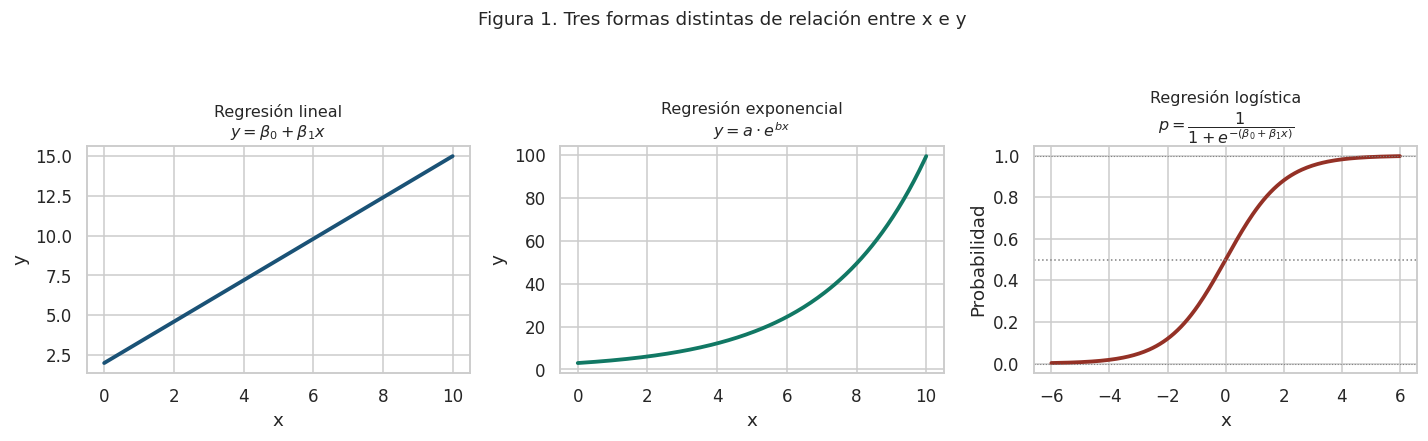

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

x = np.linspace(0, 10, 200)

# Lineal
y_lin = 2 + 1.3*x
axes[0].plot(x, y_lin, color="#1a5276", lw=2.5)
axes[0].set_title("Regresión lineal\n$y = \\beta_0 + \\beta_1 x$", fontsize=10.5)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

# Exponencial
y_exp = 3*np.exp(0.35*x)
axes[1].plot(x, y_exp, color="#117864", lw=2.5)
axes[1].set_title("Regresión exponencial\n$y = a \\cdot e^{bx}$", fontsize=10.5)
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

# Logistica (sigmoide)
x2 = np.linspace(-6, 6, 200)
y_log = 1/(1+np.exp(-x2))
axes[2].plot(x2, y_log, color="#943126", lw=2.5)
axes[2].axhline(0.5, color="grey", linestyle=":", lw=1)
axes[2].axhline(1, color="grey", linestyle=":", lw=0.7)
axes[2].axhline(0, color="grey", linestyle=":", lw=0.7)
axes[2].set_title("Regresión logística\n$p = \\dfrac{1}{1+e^{-(\\beta_0+\\beta_1 x)}}$", fontsize=10.5)
axes[2].set_xlabel("x"); axes[2].set_ylabel("Probabilidad")

plt.suptitle("Figura 1. Tres formas distintas de relación entre x e y", y=1.05, fontsize=12)
plt.tight_layout()
plt.show()

**Cómo leer la Figura 1:**

- El panel **izquierdo** es la regresión lineal que ya conoces: por cada unidad que aumenta $x$, $y$ aumenta siempre lo mismo (una cantidad fija, $\beta_1$).
- El panel **central** es una **regresión exponencial**: por cada unidad que aumenta $x$, $y$ no aumenta una cantidad fija, sino que se **multiplica** por un factor constante. Así se ve el crecimiento de un brote de una enfermedad en su fase temprana, o el crecimiento de un cultivo de bacterias.
- El panel **derecho** es una **regresión logística**: la variable respuesta está acotada entre 0 y 1 (es una *probabilidad*), y tiene forma de "S" (función sigmoide). Así se modela, por ejemplo, la probabilidad de que ocurra un evento (sí/no) en función de una o más variables.

## 1.3 Variable respuesta: la pregunta que define qué modelo usar

La elección del modelo **no es una preferencia estética** — depende, ante todo, del tipo de variable que se quiere predecir:

| Tipo de variable respuesta | Ejemplo en nuestro caso | Modelo adecuado |
|---|---|---|
| Continua, con relación aproximadamente lineal | — | Regresión lineal |
| Continua positiva, que crece o decrece multiplicativamente en el tiempo | Número de plantas infectadas por semana | **Regresión exponencial** |
| Categórica binaria (dos clases) | ¿La finca tendrá un brote severo? (Sí/No) | **Regresión logística** |

En las siguientes dos secciones desarrollaremos, uno por uno, estos dos modelos — siempre sobre nuestro caso de la roya del café.

> **Preguntas de discusión — Sección 1**
> 1. Si intentáramos ajustar una regresión lineal directamente sobre el número de plantas infectadas por semana (sin transformar los datos), ¿qué problema práctico tendría esa recta si la usáramos para proyectar 10 semanas hacia el futuro?
> 2. Piensa en tu propio campo de trabajo: ¿se te ocurre una variable que se comporte de forma "multiplicativa" (exponencial) en vez de "aditiva" (lineal)?
> 3. ¿Por qué crees que una recta ($y = \beta_0 + \beta_1 x$) no es una buena idea para modelar directamente una probabilidad (que debe estar siempre entre 0 y 1)?


---
# 2. Regresión Exponencial: Conceptos y Aplicaciones

## 2.1 Introducción a la regresión exponencial

**Definición formal:** la regresión exponencial modela una variable respuesta $y$ que crece (o decrece) de forma **proporcional a su propio valor actual** conforme cambia $x$ (usualmente el tiempo). El modelo tiene la forma:

$$y = a \cdot e^{bx}$$

donde:

- $a$ es el **valor inicial** de $y$ (cuando $x=0$).
- $b$ es la **tasa de crecimiento continuo**: si $b>0$, $y$ crece (crecimiento exponencial); si $b<0$, $y$ decrece (decaimiento exponencial, como la desintegración radiactiva o la eliminación de un medicamento en el cuerpo).

**El truco para ajustarlo con herramientas de regresión lineal:** si aplicamos logaritmo natural a ambos lados de la ecuación, el modelo se vuelve **lineal**:

$$\ln(y) = \ln(a) + bx$$

Esto es exactamente la ecuación de una recta, donde el "intercepto" es $\ln(a)$ y la "pendiente" es $b$. Esta transformación (llamada **linearización**) es la razón por la cual podemos usar las mismas herramientas de regresión lineal para ajustar un modelo exponencial.

## 2.2 Interpretación de los coeficientes

- **$a$ (valor inicial):** tiene las mismas unidades que $y$. En nuestro caso, sería el número de plantas infectadas en el momento de la primera detección ($x=0$).
- **$b$ (tasa de crecimiento):** se interpreta como *la proporción de cambio por cada unidad de $x$*. Por ejemplo, si $b = 0.35$ por semana, $y$ se multiplica aproximadamente por $e^{0.35} \approx 1.42$ cada semana — es decir, **crece un 42% cada semana**.
- **Tiempo de duplicación:** una métrica derivada muy usada en epidemiología y biología, que responde *"¿cada cuánto se duplica $y$?"*:

$$t_{duplicación} = \frac{\ln(2)}{b}$$

## 2.3 Aplicaciones prácticas en salud y biología

La regresión exponencial es el modelo de referencia para fenómenos como:

- **Curvas epidémicas en su fase temprana** (antes de que las medidas de contención o la inmunidad de la población cambien la dinámica).
- **Crecimiento de poblaciones biológicas** (bacterias, colonias celulares, plagas agrícolas — como en nuestro caso).
- **Farmacocinética**: la eliminación de un medicamento del torrente sanguíneo suele modelarse como decaimiento exponencial ($b<0$).
- **Desintegración radiactiva** y datación por carbono-14.


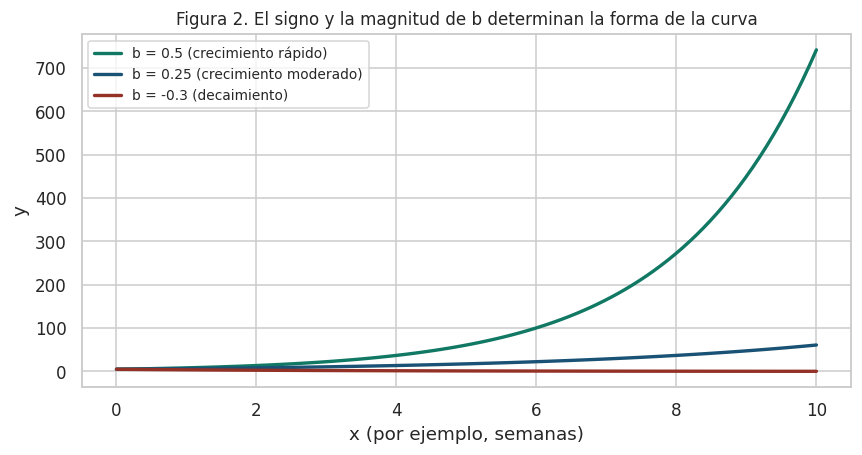

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.3))

x_demo = np.linspace(0, 10, 100)
for b_demo, color, label in [(0.5, "#117864", "b = 0.5 (crecimiento rápido)"),
                              (0.25, "#1a5276", "b = 0.25 (crecimiento moderado)"),
                              (-0.3, "#943126", "b = -0.3 (decaimiento)")]:
    ax.plot(x_demo, 5*np.exp(b_demo*x_demo), label=label, lw=2.2, color=color)

ax.set_xlabel("x (por ejemplo, semanas)")
ax.set_ylabel("y")
ax.legend(fontsize=9)
plt.title("Figura 2. El signo y la magnitud de b determinan la forma de la curva", fontsize=11)
plt.tight_layout()
plt.show()

## 2.4 Aplicándolo a nuestro caso: la propagación de la roya

**Contexto:** el equipo técnico de la Cooperativa visita semanalmente una de las fincas afectadas y cuenta el número acumulado de plantas con síntomas visibles de roya, desde la semana de la primera detección ($x=0$).


In [ ]:
np.random.seed(7)

semanas = np.arange(0, 8)  # semana 0 a semana 7
a_real, b_real = 6.0, 0.35  # parámetros "verdaderos" (desconocidos en la práctica)
y_esperado = a_real * np.exp(b_real * semanas)
ruido = np.random.normal(0, 1, size=len(semanas)) * (y_esperado * 0.06)
plantas_infectadas = np.clip(np.round(y_esperado + ruido), 1, None)

df_roya = pd.DataFrame({"semana": semanas, "plantas_infectadas": plantas_infectadas})
df_roya

,semana,plantas_infectadas
0,0,7.0
1,1,8.0
2,2,12.0
3,3,18.0
4,4,23.0
5,5,35.0
6,6,49.0
7,7,62.0


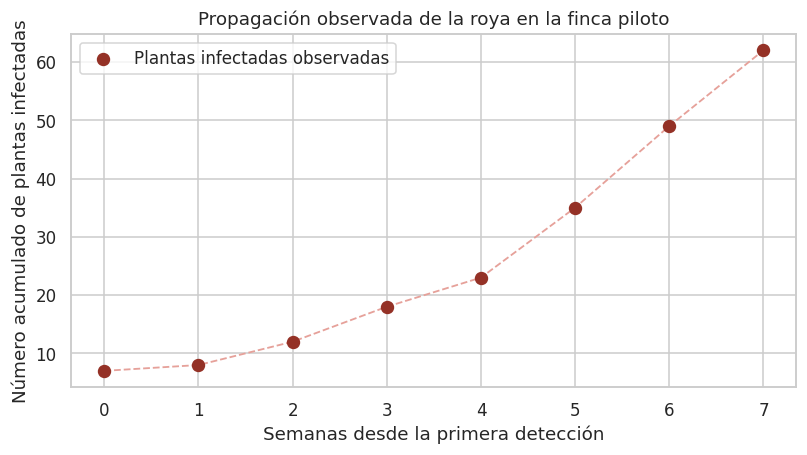

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.scatter(df_roya["semana"], df_roya["plantas_infectadas"], color="#943126", s=60, zorder=3,
           label="Plantas infectadas observadas")
ax.plot(df_roya["semana"], df_roya["plantas_infectadas"], color="#e6a19a", linestyle="--", lw=1.2, zorder=2)
ax.set_xlabel("Semanas desde la primera detección")
ax.set_ylabel("Número acumulado de plantas infectadas")
ax.set_title("Propagación observada de la roya en la finca piloto")
ax.legend()
plt.tight_layout()
plt.show()

**Explicación del código:** `np.clip(..., 1, None)` asegura que ningún valor simulado sea menor a 1 (no tendría sentido un número negativo o cero de plantas infectadas, dado que ya hubo detección en la semana 0). El resto es el mismo patrón que usamos en la sesión anterior: simulamos con `numpy` y organizamos en un `DataFrame` de `pandas`.

A simple vista, la curva **no luce como una línea recta** — crece cada vez más rápido. Vamos a confirmarlo formalmente ajustando un modelo exponencial.

### Paso 1: Linearización y ajuste con regresión lineal (`scikit-learn`)

Aplicamos logaritmo natural a la variable respuesta, y ajustamos una regresión lineal simple entre `semana` y `ln(plantas_infectadas)`.


In [ ]:
df_roya["log_plantas"] = np.log(df_roya["plantas_infectadas"])

X = df_roya[["semana"]]          # scikit-learn espera una matriz 2D para los predictores
y_log = df_roya["log_plantas"]   # variable respuesta transformada

modelo_exp = LinearRegression()
modelo_exp.fit(X, y_log)

b_estimado = modelo_exp.coef_[0]
a_estimado = np.exp(modelo_exp.intercept_)

print(f"Pendiente (b estimado):     {b_estimado:.4f}")
print(f"Intercepto (ln(a)):         {modelo_exp.intercept_:.4f}")
print(f"a estimado (valor inicial): {a_estimado:.3f}")
print(f"R² del modelo linearizado:  {modelo_exp.score(X, y_log):.4f}")

Pendiente (b estimado):     0.3308
Intercepto (ln(a)):         1.8560
a estimado (valor inicial): 6.398
R² del modelo linearizado:  0.9933


**Explicación del código:**
- `LinearRegression()` de `scikit-learn` crea un objeto de modelo de regresión lineal (todavía sin entrenar).
- `.fit(X, y_log)`: entrena (ajusta) el modelo, encontrando la pendiente y el intercepto que mejor se ajustan a los datos transformados.
- `.coef_[0]`: la pendiente estimada — en `scikit-learn`, los coeficientes siempre se devuelven como un arreglo (por eso el `[0]`, para tomar el primero y único predictor).
- `.intercept_`: el intercepto estimado. Como transformamos $y$ con logaritmo, el intercepto corresponde a $\ln(a)$, así que aplicamos `np.exp()` para recuperar $a$ en su escala original.
- `.score(X, y_log)`: devuelve el $R^2$ del modelo — qué proporción de la variabilidad de `log_plantas` es explicada por `semana`.

### Paso 2: Proyección y tiempo de duplicación


Tiempo de duplicación estimado: 2.10 semanas


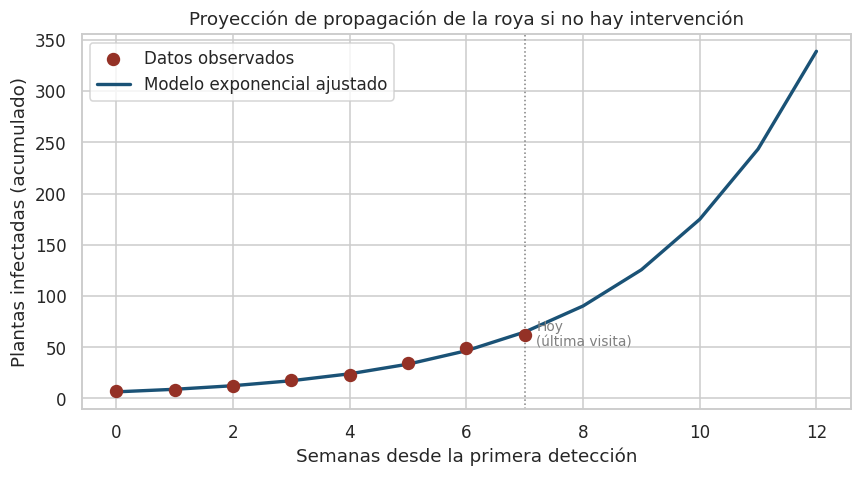


Proyección para la semana 12 (5 semanas hacia adelante): 339 plantas infectadas


In [ ]:
tiempo_duplicacion = np.log(2) / b_estimado
print(f"Tiempo de duplicación estimado: {tiempo_duplicacion:.2f} semanas")

# Proyectamos 5 semanas adicionales
semanas_futuras = np.arange(0, 13)
proyeccion = a_estimado * np.exp(b_estimado * semanas_futuras)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(df_roya["semana"], df_roya["plantas_infectadas"], color="#943126", s=60, zorder=3, label="Datos observados")
ax.plot(semanas_futuras, proyeccion, color="#1a5276", lw=2.2, label="Modelo exponencial ajustado")
ax.axvline(7, color="grey", linestyle=":", lw=1)
ax.text(7.2, proyeccion.max()*0.15, "Hoy\n(última visita)", fontsize=9, color="grey")
ax.set_xlabel("Semanas desde la primera detección")
ax.set_ylabel("Plantas infectadas (acumulado)")
ax.legend()
plt.title("Proyección de propagación de la roya si no hay intervención")
plt.tight_layout()
plt.show()

print(f"\nProyección para la semana 12 (5 semanas hacia adelante): {proyeccion[-1]:.0f} plantas infectadas")

### Paso 3: Verificación con ajuste no lineal directo (`scipy.optimize.curve_fit`)

La linearización es una forma práctica de aprovechar herramientas de regresión lineal, pero también podemos ajustar la función exponencial **directamente**, sin transformar los datos, usando optimización numérica.


In [ ]:
def funcion_exponencial(x, a, b):
    return a * np.exp(b * x)

# p0 son valores iniciales razonables para que el algoritmo de optimización empiece a buscar
parametros_opt, _ = curve_fit(funcion_exponencial, df_roya["semana"], df_roya["plantas_infectadas"], p0=[5, 0.3])

print(f"a estimado (curve_fit): {parametros_opt[0]:.3f}")
print(f"b estimado (curve_fit): {parametros_opt[1]:.4f}")
print(f"\n(Compara estos valores con los obtenidos por linearización: a={a_estimado:.3f}, b={b_estimado:.4f})")

a estimado (curve_fit): 6.803
b estimado (curve_fit): 0.3198

(Compara estos valores con los obtenidos por linearización: a=6.398, b=0.3308)


**Explicación del código:** `curve_fit(funcion, x, y, p0)` de `scipy.optimize` recibe una función arbitraria (aquí, nuestra función exponencial), los datos observados, y un punto de partida (`p0`) para los parámetros. Internamente usa un algoritmo iterativo (mínimos cuadrados no lineales) que ajusta los parámetros hasta minimizar el error de predicción. A diferencia de la linearización, este método **no requiere transformar los datos**, pero es computacionalmente más costoso y puede ser sensible al valor inicial `p0` en modelos más complejos.

Es tranquilizador ver que ambos métodos —linearización y ajuste no lineal directo— arrojan resultados muy similares. Esto no siempre ocurre: la linearización asume que el error se distribuye de cierta forma en la escala logarítmica, mientras que `curve_fit` optimiza directamente en la escala original — para datos con mucho ruido, pueden diferir.

> **Preguntas de discusión — Sección 2**
> 1. Con un tiempo de duplicación de aproximadamente 2 semanas, si la Cooperativa tarda 3 semanas en aprobar y ejecutar un plan de fumigación, ¿cuántas plantas adicionales (aproximadamente) se infectarán solo por ese tiempo de espera?
> 2. El modelo exponencial que ajustamos asume que la tasa de crecimiento $b$ se mantiene constante indefinidamente. ¿Qué factores reales en el cultivo de café podrían hacer que, después de varias semanas, el crecimiento deje de ser exponencial y empiece a desacelerarse?
> 3. Si en lugar de modelar la propagación de la roya quisiéramos modelar cuántos días tarda un fungicida en perder efectividad en la hoja del cafeto, ¿qué signo esperarías para $b$, y por qué?


---
# 3. Regresión Logística: Introducción y Casos de Uso

## 3.1 Fundamentos de la regresión logística

**Definición formal:** la regresión logística modela la **probabilidad** de que ocurra un evento binario (dos posibles resultados: sí/no, 1/0) en función de una o más variables predictoras. En lugar de modelar directamente la probabilidad $p$ (que debe estar entre 0 y 1), modela el **logaritmo de la razón de odds** (log-odds o *logit*) como una función lineal de los predictores:

$$\text{logit}(p) = \ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_k x_k$$

Despejando $p$, obtenemos la **función logística (sigmoide)** que vimos en la Figura 1:

$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_k x_k)}}$$

Esta transformación logra dos cosas al mismo tiempo: (1) garantiza que $p$ siempre esté entre 0 y 1, sin importar los valores de los predictores, y (2) nos permite seguir usando una combinación **lineal** de los predictores, solo que ahora en la escala del logit.

## 3.2 Interpretación de los coeficientes

Los coeficientes $\beta_i$ de una regresión logística **no se interpretan igual que en una regresión lineal** — no representan un cambio directo en $p$, sino un cambio en el **log-odds**. Para interpretarlos de forma más intuitiva, se suele exponenciar el coeficiente para obtener el **odds ratio (razón de odds)**:

$$OR_i = e^{\beta_i}$$

- Si $OR_i > 1$: por cada unidad que aumenta $x_i$ (manteniendo las demás variables fijas), los odds de que ocurra el evento **aumentan** en un factor de $OR_i$.
- Si $OR_i < 1$: los odds **disminuyen**.
- Si $OR_i = 1$ ($\beta_i = 0$): la variable no tiene efecto.

Por ejemplo: si $OR = 1.5$ para una variable, significa que por cada unidad adicional de esa variable, los odds del evento se multiplican por 1.5 (aumentan 50%).

## 3.3 Casos de uso

La regresión logística es, probablemente, el modelo de clasificación más usado en la práctica profesional, porque combina buen poder predictivo con **alta interpretabilidad**:

- **Marketing:** probabilidad de que un cliente responda a una campaña, o cancele su suscripción (*churn*).
- **Análisis de riesgo crediticio:** probabilidad de que un solicitante de crédito incumpla su pago (*default*).
- **Salud:** probabilidad de que un paciente desarrolle una complicación, dado un conjunto de factores clínicos.
- **Agricultura (nuestro caso):** probabilidad de que una finca sufra un brote severo de una plaga, dado un conjunto de condiciones agronómicas.


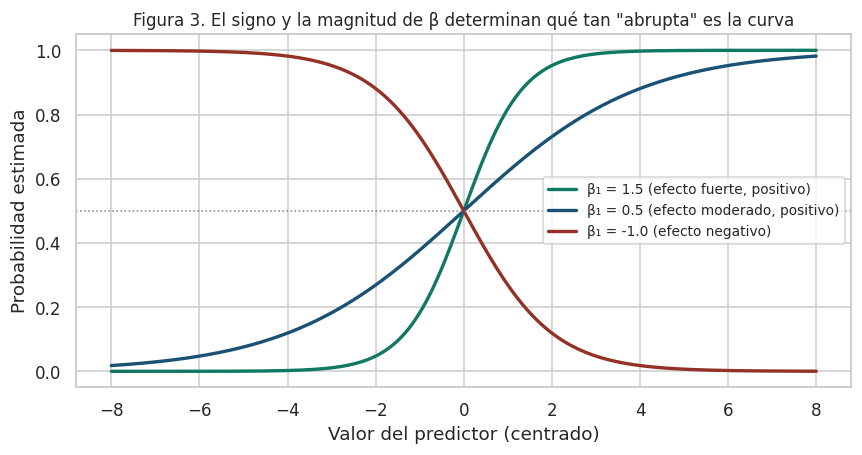

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.3))

x_demo = np.linspace(-8, 8, 200)
for beta_demo, color, label in [(1.5, "#117864", "β₁ = 1.5 (efecto fuerte, positivo)"),
                                  (0.5, "#1a5276", "β₁ = 0.5 (efecto moderado, positivo)"),
                                  (-1.0, "#943126", "β₁ = -1.0 (efecto negativo)")]:
    p_demo = 1/(1+np.exp(-(beta_demo*x_demo)))
    ax.plot(x_demo, p_demo, label=label, lw=2.2, color=color)

ax.axhline(0.5, color="grey", linestyle=":", lw=1)
ax.set_xlabel("Valor del predictor (centrado)")
ax.set_ylabel("Probabilidad estimada")
ax.legend(fontsize=9)
plt.title("Figura 3. El signo y la magnitud de β determinan qué tan \"abrupta\" es la curva", fontsize=11)
plt.tight_layout()
plt.show()

**Cómo leer la Figura 3:** entre más grande (en valor absoluto) sea el coeficiente $\beta$, más **abrupta** es la transición de probabilidad baja a probabilidad alta — es decir, la variable predictora es más "decisiva". Un coeficiente negativo simplemente invierte la dirección de la curva.

## 3.4 Aplicándolo a nuestro caso: riesgo de brote severo

**Contexto:** el equipo técnico de la Cooperativa recopiló información de 480 fincas afectadas por la roya durante la temporada pasada, incluyendo si cada finca terminó con un **brote severo** (pérdida de más del 30% de la cosecha) y varias características agronómicas medidas al inicio del brote.


In [ ]:
np.random.seed(55)

n = 480
humedad_relativa = np.random.normal(80, 8, n)     # % de humedad relativa promedio
altitud_msnm = np.random.normal(1400, 250, n)     # metros sobre el nivel del mar
densidad_siembra = np.random.normal(5000, 800, n) # plantas por hectárea
fungicida_preventivo = np.random.binomial(1, 0.5, n)  # 1 = sí aplicó fungicida preventivo
sombrio_pct = np.random.normal(40, 15, n)         # % de cobertura de sombrío

# Variables centradas y escaladas, usadas únicamente para construir el escenario simulado
hum_c = (humedad_relativa - 80) / 8
alt_c = (altitud_msnm - 1400) / 250
den_c = (densidad_siembra - 5000) / 800
somb_c = (sombrio_pct - 40) / 15

logit_real = -0.6 + 0.9*hum_c - 0.7*alt_c - 1.3*fungicida_preventivo + 0.4*somb_c + 0.25*den_c
prob_real = 1 / (1 + np.exp(-logit_real))
brote_severo = np.random.binomial(1, prob_real)

df_fincas = pd.DataFrame({
    "humedad_relativa": humedad_relativa,
    "altitud_msnm": altitud_msnm,
    "densidad_siembra": densidad_siembra,
    "fungicida_preventivo": fungicida_preventivo,
    "sombrio_pct": sombrio_pct,
    "brote_severo": brote_severo
})

print(f"Proporción de fincas con brote severo: {df_fincas['brote_severo'].mean():.2%}")
df_fincas.head()

Proporción de fincas con brote severo: 26.46%


,humedad_relativa,altitud_msnm,densidad_siembra,fungicida_preventivo,sombrio_pct,brote_severo
0,67.010151,1262.611996,6637.048363,1,21.908561,0
1,79.185729,1299.463919,4899.288421,1,50.483207,1
2,65.521671,1277.633894,4862.378263,1,45.728337,0
3,82.101231,958.987036,5527.993544,0,45.783685,0
4,82.079621,1551.072701,3873.332500,1,17.904475,1


/tmp/ipykernel_1938/2990342641.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fincas, x="brote_severo", y="humedad_relativa", ax=axes[0], palette=["#1a5276", "#943126"])
/tmp/ipykernel_1938/2990342641.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No severo", "Severo"])
/tmp/ipykernel_1938/2990342641.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fincas, x="brote_severo", y="altitud_msnm", ax=axes[1], palette=["#1a5276", "#943126"])
/tmp/ipykernel_1938/2990342641.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e

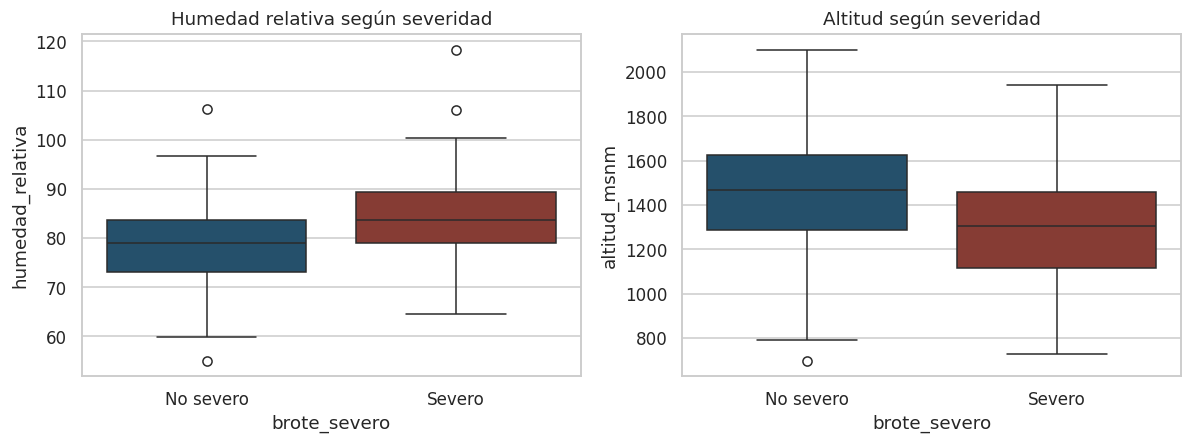

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.boxplot(data=df_fincas, x="brote_severo", y="humedad_relativa", ax=axes[0], palette=["#1a5276", "#943126"])
axes[0].set_xticklabels(["No severo", "Severo"])
axes[0].set_title("Humedad relativa según severidad")

sns.boxplot(data=df_fincas, x="brote_severo", y="altitud_msnm", ax=axes[1], palette=["#1a5276", "#943126"])
axes[1].set_xticklabels(["No severo", "Severo"])
axes[1].set_title("Altitud según severidad")

plt.tight_layout()
plt.show()

### Paso 1: Ajuste con `statsmodels` (para interpretar coeficientes y odds ratios)

Igual que en la sesión anterior, empezamos con `statsmodels` cuando el objetivo es **interpretar** el modelo (obtener coeficientes, errores estándar y valores p), y luego usaremos `scikit-learn` cuando el objetivo sea **predecir y evaluar** el modelo (Sección 4).


In [ ]:
X_vars = ["humedad_relativa", "altitud_msnm", "densidad_siembra", "fungicida_preventivo", "sombrio_pct"]
X = df_fincas[X_vars]
y = df_fincas["brote_severo"]

X_con_constante = sm.add_constant(X)   # agrega la columna de 1's necesaria para estimar el intercepto (beta_0)
modelo_logit = sm.Logit(y, X_con_constante).fit(disp=0)

print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:           brote_severo   No. Observations:                  480
Model:                          Logit   Df Residuals:                      474
Method:                           MLE   Df Model:                            5
Date:                Sat, 05 Sep 2026   Pseudo R-squ.:                  0.2364
Time:                        04:02:55   Log-Likelihood:                -211.78
converged:                       True   LL-Null:                       -277.34
Covariance Type:            nonrobust   LLR p-value:                 1.369e-26
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -6.7502      1.654     -4.081      0.000      -9.992      -3.509
humedad_relativa         0.1052      0.017      6.173      0.000       0.072       0.139
altitud_msnm

**Explicación del código:**
- `sm.add_constant(X)`: `statsmodels` no agrega automáticamente un intercepto — hay que añadir explícitamente una columna de unos, que representa $\beta_0$.
- `sm.Logit(y, X)`: define el modelo de regresión logística, con `y` la variable respuesta binaria y `X` los predictores.
- `.fit(disp=0)`: ajusta el modelo por máxima verosimilitud (el método estándar para regresión logística, análogo a mínimos cuadrados en regresión lineal). `disp=0` simplemente evita que se impriman mensajes del proceso de optimización.
- El resumen (`summary()`) muestra, para cada variable: el coeficiente (`coef`), su error estándar, el estadístico z, y el valor p (`P>|z|`) — exactamente el mismo tipo de prueba de hipótesis que estudiamos en la sesión anterior, pero aplicada ahora a cada coeficiente del modelo (H₀: el coeficiente es igual a 0, es decir, la variable no tiene efecto).

### Paso 2: Traduciendo coeficientes a odds ratios


In [ ]:
odds_ratios = np.exp(modelo_logit.params)
tabla_or = pd.DataFrame({
    "Coeficiente (log-odds)": modelo_logit.params,
    "Odds Ratio": odds_ratios,
    "Valor p": modelo_logit.pvalues
}).round(4)
tabla_or

,Coeficiente (log-odds),Odds Ratio,Valor p
const,-6.7502,0.0012,0.0000
humedad_relativa,0.1052,1.1110,0.0000
altitud_msnm,-0.0030,0.9970,0.0000
densidad_siembra,0.0002,1.0002,0.2031
fungicida_preventivo,-1.4298,0.2394,0.0000
sombrio_pct,0.0236,1.0238,0.0048


**Explicación del código:** `np.exp()` aplicado a los coeficientes los convierte de la escala de log-odds a la escala de odds ratio, tal como vimos en la Sección 3.2.

**Interpretación de negocio de cada variable:**

- **`humedad_relativa`** (OR > 1, p < 0.05): cada punto porcentual adicional de humedad relativa promedio **aumenta** los momios de un brote severo. Tiene sentido agronómico: la roya prospera en ambientes húmedos.
- **`altitud_msnm`** (OR < 1, p < 0.05): a mayor altitud, **menores** los momios de brote severo — las zonas más altas suelen tener temperaturas más bajas, menos favorables para el hongo.
- **`fungicida_preventivo`** (OR << 1, p < 0.05): aplicar fungicida preventivo **reduce sustancialmente** los momios de un brote severo. Esta es, con diferencia, la variable más “accionable” para la Cooperativa.
- **`sombrio_pct`** (OR > 1, p < 0.05): más cobertura de sombrío se asocia con mayor riesgo, probablemente porque retiene humedad alrededor de la planta.
- **`densidad_siembra`** (p > 0.05): **no encontramos evidencia suficiente** de que la densidad de siembra, por sí sola, afecte el riesgo de brote severo, una vez controlamos por las demás variables. Esto no significa que la densidad de siembra sea irrelevante en términos agronómicos generales — solo que, en esta muestra, no aporta información adicional más allá de las otras 4 variables.

> **Preguntas de discusión — Sección 3**
> 1. Si la Cooperativa solo tiene presupuesto para reforzar **una** de las cuatro variables significativas en las fincas de mayor riesgo, ¿cuál priorizarías, y por qué (piensa tanto en el tamaño del efecto como en qué tan fácil es intervenir esa variable)?
> 2. La variable `densidad_siembra` no resultó significativa. ¿Qué le dirías a un ingeniero agrónomo que insiste en que "todo el mundo sabe" que la densidad de siembra es clave para el riesgo de roya?
> 3. El odds ratio de `fungicida_preventivo` representa una reducción muy grande en los momios de brote severo. ¿Qué información adicional (más allá de este modelo) le pedirías al equipo técnico antes de recomendar la aplicación obligatoria de fungicida preventivo a todas las 600 fincas de la Cooperativa?


---
# 4. Implementación de Modelos de Regresión No Lineales

En la Sección 3 usamos `statsmodels` para **interpretar** el modelo logístico (coeficientes, odds ratios, valores p). Ahora vamos a usar `scikit-learn` — la librería estándar de la industria para **entrenar y evaluar** modelos predictivos — y a comparar explícitamente ambos modelos no lineales contra qué pasaría si, por error, usáramos regresión lineal.

## 4.1 Regresión logística con `scikit-learn`: entrenar, predecir y evaluar

A diferencia de `statsmodels`, `scikit-learn` está diseñado pensando en el flujo completo de un proyecto de machine learning: separar datos de entrenamiento y prueba, escalar variables, entrenar, predecir, y evaluar con métricas de clasificación.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Fincas de entrenamiento: {len(X_train)}")
print(f"Fincas de prueba:        {len(X_test)}")
print(f"Proporción de brote severo en entrenamiento: {y_train.mean():.2%}")
print(f"Proporción de brote severo en prueba:        {y_test.mean():.2%}")

Fincas de entrenamiento: 360
Fincas de prueba:        120
Proporción de brote severo en entrenamiento: 26.39%
Proporción de brote severo en prueba:        26.67%


**Explicación del código:**
- `train_test_split(X, y, test_size=0.25, ...)`: divide los datos en un conjunto de **entrenamiento** (75% de las fincas, usado para ajustar el modelo) y uno de **prueba** (25%, reservado para evaluar qué tan bien generaliza el modelo a fincas que no vio durante el entrenamiento). Esta división es la base de toda evaluación honesta de un modelo predictivo: evaluar el modelo sobre los mismos datos con los que se entrenó tiende a sobreestimar su desempeño real.
- `stratify=y`: asegura que la proporción de fincas con brote severo sea similar en ambos conjuntos (entrenamiento y prueba) — importante cuando, como aquí, una de las dos clases es menos frecuente.
- `random_state=42`: fija la semilla aleatoria de la división, para que el resultado sea reproducible.


In [ ]:
escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_test_esc = escalador.transform(X_test)

modelo_clf = LogisticRegression()
modelo_clf.fit(X_train_esc, y_train)

y_pred = modelo_clf.predict(X_test_esc)
y_proba = modelo_clf.predict_proba(X_test_esc)[:, 1]

print("Coeficientes (en escala estandarizada):")
for var, coef in zip(X_vars, modelo_clf.coef_[0]):
    print(f"  {var:22s}: {coef:+.3f}")

Coeficientes (en escala estandarizada):
  humedad_relativa      : +0.818
  altitud_msnm          : -0.657
  densidad_siembra      : +0.069
  fungicida_preventivo  : -0.674
  sombrio_pct           : +0.370


**Explicación del código:**
- `StandardScaler()`: estandariza cada variable para que tenga media 0 y desviación estándar 1. Esto es una buena práctica en `scikit-learn` (aunque no estrictamente obligatoria para regresión logística) porque pone a todas las variables en la misma escala, evitando que una variable con números muy grandes (como `altitud_msnm`, en cientos) domine artificialmente sobre una variable con números pequeños (como `fungicida_preventivo`, que es 0 o 1).
- `.fit_transform(X_train)`: calcula la media y desviación estándar **sobre el conjunto de entrenamiento**, y transforma esos mismos datos.
- `.transform(X_test)`: aplica esa **misma** transformación (calculada con los datos de entrenamiento) al conjunto de prueba — nunca se debe "reajustar" el escalador con los datos de prueba, porque eso filtraría información del conjunto de prueba hacia el entrenamiento (una forma sutil de *data leakage*).
- `LogisticRegression()` y `.fit(...)`: igual que vimos con `LinearRegression` en la Sección 2, se crea el objeto de modelo y se entrena.
- `.predict(X_test_esc)`: devuelve la clase predicha (0 o 1) para cada finca de prueba.
- `.predict_proba(X_test_esc)[:, 1]`: devuelve la **probabilidad** estimada de la clase 1 (brote severo) para cada finca — esto es lo que realmente calcula el modelo antes de convertirlo en una decisión binaria con un umbral (por defecto, 0.5).

### Evaluación del modelo


In [ ]:
exactitud = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
matriz_confusion = confusion_matrix(y_test, y_pred)

print(f"Exactitud (accuracy):        {exactitud:.3f}")
print(f"Área bajo la curva ROC (AUC): {auc:.3f}")
print("\nMatriz de confusión:")
print(pd.DataFrame(matriz_confusion,
                    index=["Real: No severo", "Real: Severo"],
                    columns=["Predicho: No severo", "Predicho: Severo"]))

Exactitud (accuracy):        0.825
Área bajo la curva ROC (AUC): 0.847

Matriz de confusión:
                 Predicho: No severo  Predicho: Severo
Real: No severo                   85                 3
Real: Severo                      18                14


**Explicación del código:**
- **Exactitud (`accuracy_score`)**: proporción de fincas clasificadas correctamente (severo o no severo) sobre el total. Es intuitiva, pero puede ser engañosa cuando las clases están desbalanceadas.
- **AUC (`roc_auc_score`)**: mide qué tan bien el modelo **ordena** las fincas por riesgo, independientemente del umbral de decisión que se use. Un valor de 0.5 equivale a adivinar al azar; 1.0 sería clasificación perfecta.
- **Matriz de confusión (`confusion_matrix`)**: desglosa los aciertos y errores en 4 categorías. Para la Cooperativa, el error más costoso probablemente sea predecir "no severo" cuando en realidad la finca sí tuvo un brote severo (un **falso negativo**) — porque significa no intervenir a tiempo una finca que lo necesitaba.


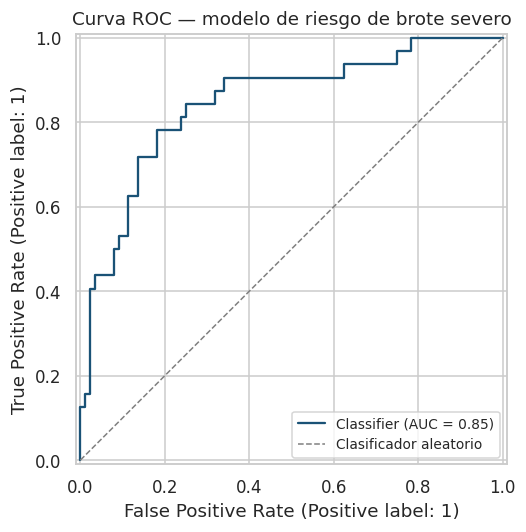

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, color="#1a5276")
ax.plot([0,1],[0,1], linestyle="--", color="grey", lw=1, label="Clasificador aleatorio")
ax.set_title("Curva ROC — modelo de riesgo de brote severo")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Explicación del código:** `RocCurveDisplay.from_predictions(y_real, y_probabilidad)` construye automáticamente la curva ROC (que grafica la tasa de verdaderos positivos contra la tasa de falsos positivos, para todos los posibles umbrales de decisión) y calcula el área bajo la curva.

### Prediciendo el riesgo de una finca nueva

Supongamos que una finca nueva se une a la Cooperativa, con las siguientes condiciones: 85% de humedad relativa, 1,200 m.s.n.m. de altitud, 5,400 plantas/hectárea, sin aplicación preventiva de fungicida, y 55% de cobertura de sombrío.


In [ ]:
finca_nueva = pd.DataFrame({
    "humedad_relativa": [85],
    "altitud_msnm": [1200],
    "densidad_siembra": [5400],
    "fungicida_preventivo": [0],
    "sombrio_pct": [55]
})

finca_nueva_esc = escalador.transform(finca_nueva)
probabilidad_riesgo = modelo_clf.predict_proba(finca_nueva_esc)[0, 1]

print(f"Probabilidad estimada de brote severo: {probabilidad_riesgo:.1%}")

if probabilidad_riesgo > 0.5:
    print("Recomendación: PRIORIZAR esta finca para visita técnica preventiva.")
else:
    print("Recomendación: finca en observación rutinaria.")

Probabilidad estimada de brote severo: 68.1%
Recomendación: PRIORIZAR esta finca para visita técnica preventiva.


## 4.2 Comparación con la regresión lineal: ¿qué pasaría si la usáramos por error?

Esta comparación es, quizás, la parte más importante de la sesión de hoy: entender **qué sale mal** si usamos regresión lineal donde no corresponde, en lugar de solamente asumir que "el modelo correcto siempre funciona mejor".

### Caso 1: regresión lineal sobre el crecimiento de la roya


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


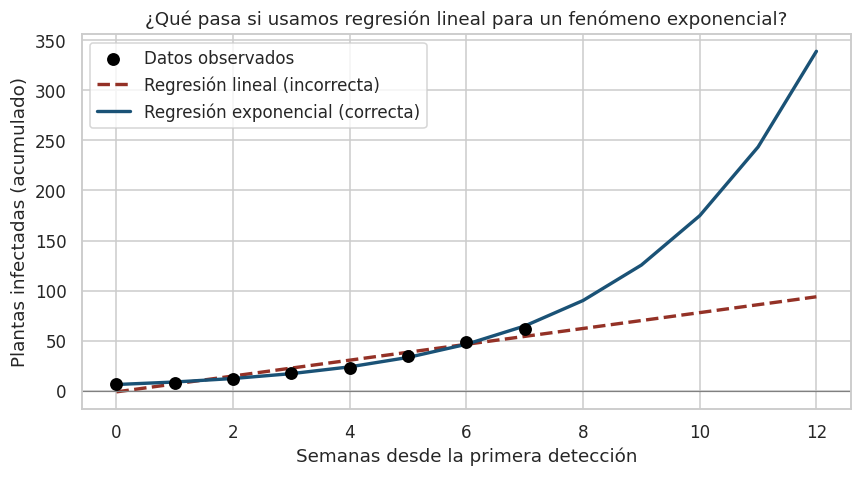

Predicción lineal en semana 0:  -0.9 plantas
Predicción exponencial en semana 0: 6.4 plantas


In [ ]:
modelo_lineal_roya = LinearRegression()
modelo_lineal_roya.fit(df_roya[["semana"]], df_roya["plantas_infectadas"])

semanas_futuras2 = np.arange(0, 13).reshape(-1, 1)
prediccion_lineal = modelo_lineal_roya.predict(semanas_futuras2)
prediccion_exp = a_estimado * np.exp(b_estimado * semanas_futuras2.flatten())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(df_roya["semana"], df_roya["plantas_infectadas"], color="black", s=55, zorder=3, label="Datos observados")
ax.plot(semanas_futuras2, prediccion_lineal, color="#943126", lw=2.2, linestyle="--", label="Regresión lineal (incorrecta)")
ax.plot(semanas_futuras2, prediccion_exp, color="#1a5276", lw=2.2, label="Regresión exponencial (correcta)")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Semanas desde la primera detección")
ax.set_ylabel("Plantas infectadas (acumulado)")
ax.legend()
plt.title("¿Qué pasa si usamos regresión lineal para un fenómeno exponencial?")
plt.tight_layout()
plt.show()

print(f"Predicción lineal en semana 0:  {prediccion_lineal[0]:.1f} plantas")
print(f"Predicción exponencial en semana 0: {prediccion_exp[0]:.1f} plantas")

Observa dos problemas concretos de usar regresión lineal aquí:

1. **En el corto plazo, subestima el crecimiento**: la curva exponencial "se pega" mejor a los primeros puntos, mientras que la recta ya empieza a desviarse desde las primeras semanas.
2. **En proyecciones hacia atrás o hacia adelante, puede producir valores sin sentido físico** (por ejemplo, un número negativo de plantas infectadas si extrapolamos hacia semanas anteriores a la primera detección) — algo que la función exponencial, por construcción, nunca puede producir (siempre da valores positivos).

### Caso 2: regresión lineal sobre una variable binaria (el "modelo de probabilidad lineal")


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


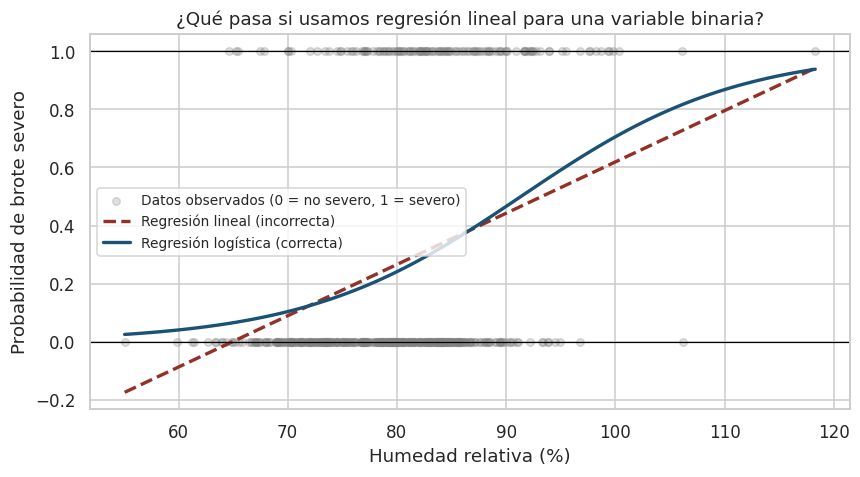

Predicción lineal con humedad=98%: 0.584
Predicción logística con humedad=98%: 0.662


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
modelo_lineal_prob = LinearRegression()
modelo_lineal_prob.fit(df_fincas[["humedad_relativa"]], df_fincas["brote_severo"])

humedad_rango = np.linspace(df_fincas["humedad_relativa"].min(), df_fincas["humedad_relativa"].max(), 100).reshape(-1,1)
pred_lineal_prob = modelo_lineal_prob.predict(humedad_rango)

modelo_logit_simple = LogisticRegression()
modelo_logit_simple.fit(df_fincas[["humedad_relativa"]], df_fincas["brote_severo"])
pred_logit_prob = modelo_logit_simple.predict_proba(humedad_rango)[:, 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(df_fincas["humedad_relativa"], df_fincas["brote_severo"], alpha=0.25, color="grey", s=25,
           label="Datos observados (0 = no severo, 1 = severo)")
ax.plot(humedad_rango, pred_lineal_prob, color="#943126", lw=2.2, linestyle="--", label="Regresión lineal (incorrecta)")
ax.plot(humedad_rango, pred_logit_prob, color="#1a5276", lw=2.2, label="Regresión logística (correcta)")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(1, color="black", lw=0.8)
ax.set_xlabel("Humedad relativa (%)")
ax.set_ylabel("Probabilidad de brote severo")
ax.legend(fontsize=9)
plt.title("¿Qué pasa si usamos regresión lineal para una variable binaria?")
plt.tight_layout()
plt.show()

print(f"Predicción lineal con humedad=98%: {modelo_lineal_prob.predict([[98]])[0]:.3f}")
print(f"Predicción logística con humedad=98%: {modelo_logit_simple.predict_proba([[98]])[0,1]:.3f}")

Aquí el problema es aún más claro: con humedad relativa alta, la regresión lineal puede predecir una "probabilidad" **mayor a 1** — un valor que, por definición, no tiene sentido. La regresión logística, gracias a la función sigmoide, nunca puede salir del rango $[0,1]$, sin importar qué tan extremos sean los valores de los predictores.

## 4.3 ¿Cuándo usar cada modelo? Guía de decisión

| Pregunta | Si la respuesta es "sí"... |
|---|---|
| ¿La variable respuesta es continua y su tasa de cambio es aproximadamente constante (aditiva)? | Usa **regresión lineal** |
| ¿La variable respuesta es continua, positiva, y cambia de forma multiplicativa (proporcional a su propio valor)? | Usa **regresión exponencial** |
| ¿La variable respuesta es categórica binaria (dos clases)? | Usa **regresión logística** |
| ¿Necesitas explicar el efecto de cada variable con precisión estadística (coeficientes, valores p)? | Complementa con **`statsmodels`** |
| ¿Necesitas entrenar, evaluar y desplegar un modelo predictivo en producción? | Usa **`scikit-learn`** |

> **Preguntas de discusión — Sección 4**
> 1. En el Caso 1 (roya), la regresión lineal subestimó el crecimiento futuro. En un contexto de negocio real, ¿qué consecuencia tendría para la Cooperativa tomar decisiones de presupuesto de fumigación basadas en esa proyección subestimada?
> 2. La matriz de confusión mostró tanto falsos positivos como falsos negativos. Si la Cooperativa solo tiene recursos para visitar preventivamente al 20% de fincas de mayor riesgo predicho, ¿cambiarías el umbral de decisión de 0.5? ¿Hacia dónde, y por qué?
> 3. ¿Por qué crees que, en la práctica profesional, muchos equipos de datos usan `statsmodels` durante la fase de análisis exploratorio/explicativo, pero cambian a `scikit-learn` cuando el modelo pasa a producción?


---
### Cierre de la sesión

Hoy extendimos nuestra caja de herramientas más allá de la regresión lineal, incorporando dos modelos que resuelven limitaciones muy concretas: la **regresión exponencial**, para fenómenos que crecen o decrecen de forma multiplicativa en el tiempo, y la **regresión logística**, para variables respuesta categóricas binarias. Ambas comparten una misma idea central: **transformar el problema** (con un logaritmo, o con una función sigmoide) para poder seguir aprovechando la simplicidad y la interpretabilidad de un modelo lineal subyacente.

Recuerda: la pregunta que debes hacerte **antes** de elegir un modelo nunca es "¿qué modelo se ve mejor?", sino **"¿qué tipo de variable respuesta tengo, y cómo se comporta realmente en el mundo que estoy modelando?"**. Un modelo estadísticamente elegante, aplicado a la variable respuesta equivocada, produce conclusiones incorrectas — a veces, como vimos, literalmente sin sentido (probabilidades mayores a 1, o cantidades negativas de plantas infectadas).
